# [1교시]

# Optimizer (옵티마이저)
## SGD (Stochastic Gradient Descent) 최적화 알고리즘 분석

### 전체 데이터셋의 평균 기울기를 계산하는 대신, 무작위로 선택된 단 하나의 데이터 샘플((i))에 대한 <br>기울기만을 활용하여 매개변수(0)를 즉각적으로 업데이트하는 최적화 방식이다.
### 딥러닝 최적화 알고리즘 전문 교수로서, 표준 수식과 경사 하강법(GD)과의 비교 분석을 포함하여 최적화 알고리즘을 분석한다.

- 배치 (Batch) : 모델 업데이트를 위해 한 번에 사용하는 데이터의 묶음이며, 전체 데이터를 다 쓰면 'Full Batch'라고 한다.
- 에포크 (Epoch) : 전체 학습 데이터셋을 한 번 모두 훑는 과정을 의미한다.
- 지역 최솟값 (Local Minimum) : 전체에서 가장 낮은 지점은 아니지만, 주변보다 낮아서 알고리즘이 갇히기 쉬운 웅덩이 같은 지점이다.
- 노이즈 (Noise) : 데이터 한 개만 보고 움직일 때 발생하는 일시적인 방향의 흔들림이며, SGD에서는 이 흔들림이 지역 최솟값을 탈출하는 동력이 된다.

## 경사 하강법(GD) vs 확률적 경사 하강법(SGD) 비교
- 두 알고리즘의 결정적 차이 분석

| 비교 항목 | 경사 하강법 (GD) | 확률적 경사 하강법 (SGD) |
| :--- | :--- | :--- |
| **데이터 사용량** | **전체 데이터셋** (All Data) | **무작위 샘플 1개** (One Sample) |
| **계산 속도** | 느림 (데이터가 많을수록 연산량 폭증) | **매우 빠름** (실시간 업데이트 가능) |
| **학습 경로** | 안정적이고 매끄러운 직선 형태 | **지그재그이며 변동이 심함 (노이즈)** |
| **수렴 특성** | 지역 최솟값(Local Minimum)에 갇힘 | 노이즈 덕분에 **지역 최솟값 탈출 유리** |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)

In [2]:
# SGD 데이터를 한개씩 처리 분류문제에 해당 특성이 잘 나타나 있음
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
X_clf_train_tensor = torch.tensor(x_train,dtype=torch.float32)
y_clf_train_tensor = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

# [2교시] ~ [3교시]

In [3]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim) -> None:
      super().__init__()
      self.fc1 = nn.Linear(input_dim, hidden_dim)
      self.relu = nn.ReLU()
      self.fc2 = nn.Linear(hidden_dim, 1 )    
    def forward(self, x):    
      x = self.relu( self.fc1(x) )    
      output = self.fc2(x) 
      return output
model_clf = BinaryClassifier(2, 16)    
model_clf

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

In [4]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model_clf.parameters(), lr=0.01, momentum=0)
x_train_dataset = TensorDataset(x_train_t, y_train_t)
x_train_loader = DataLoader(x_train_dataset, batch_size=1, shuffle=True)

NameError: name 'x_train_t' is not defined

In [5]:
# 훈련루프
from tqdm import tqdm
epochs = 100
train_losses , train_accs = [], []
for epoch in tqdm(range(epochs)):
  total_loss, total_acc = 0.0 , 0.0
  for x,y in x_train_loader:
    # 가중치 초기화
    optimizer.zero_grad()
    # forward
    predict = model_clf(x).squeeze(1)
    # loss 구하고        
    loss = criterion(predict,y)
    # backward
    loss.backward()
    # 가중치 업데이트
    optimizer.step()

    total_loss += loss.item()    
    
    predict = 1 if torch.sigmoid(predict)>=0.5 else 0
    total_acc += int(predict == int(y.item()))
  train_losses.append( total_loss / len(x_train_loader) )
  train_accs.append( total_acc / len(x_train_loader) )

  0%|          | 0/100 [00:00<?, ?it/s]


NameError: name 'x_train_loader' is not defined

ValueError: x and y must have same first dimension, but have shapes (100,) and (0,)

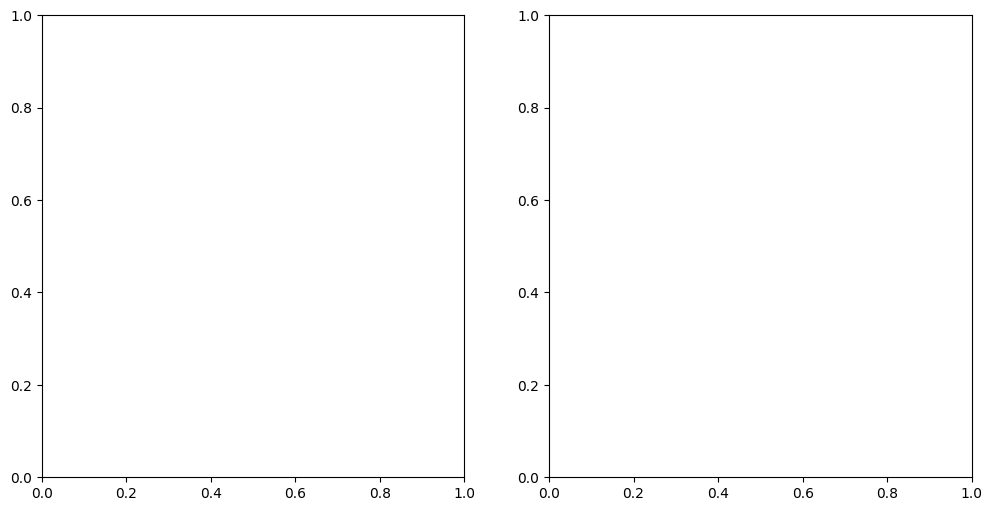

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].plot(range(epochs), train_losses, label='Train Loss')
ax[0].set_title(f"Loss: {train_losses[-1]:.4f}")
ax[0].legend()

ax[1].plot(range(epochs), train_accs, label='Train Accuracy')
ax[1].set_title(f"Acc: {train_accs[-1]:.4f}")
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# 신경망에서 sigmoide를 추가하고 손실함수는 BCELoss(sigmoid 내장 X)     BCEWithLogitsLoss(logit대상 즉 sigmoid를 내부에 적용)
# 신경망에서 마지막 출력을 2, 손실함수는 CELoss(--> softmax 내장)

In [ ]:
# 평가
with torch.no_grad():
    predict = model_clf(x_test_t).squeeze(1)
    loss = criterion(predict, y_test_t)

    predict = (torch.sigmoid(predict) >= 0.5).float()
    print(f'{loss:.4f}')
    print(accuracy_score(y_test_t, predict))

# [4교시]

## 회귀

In [7]:
# 회귀 데이터 생성
X_reg, y_reg = make_regression(
    n_samples=300,
    n_features=5,
    n_informative=5,
    noise=20.0,
    random_state=42
)
# 데이터 정규화
scaler_X_reg = StandardScaler()
X_reg = scaler_X_reg.fit_transform(X_reg)

scaler_y_reg = StandardScaler()
y_reg = scaler_y_reg.fit_transform(y_reg.reshape(-1, 1)).flatten()

# 학습/테스트 분할 (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# PyTorch 텐서로 변환
X_reg_train_tensor = torch.FloatTensor(X_reg_train)
y_reg_train_tensor = torch.FloatTensor(y_reg_train).reshape(-1, 1)
X_reg_test_tensor = torch.FloatTensor(X_reg_test)
y_reg_test_tensor = torch.FloatTensor(y_reg_test).reshape(-1, 1)

print(f"회귀 데이터셋 생성 완료")
print(f"훈련 데이터: {X_reg_train_tensor.shape}")
print(f"테스트 데이터: {X_reg_test_tensor.shape}")
print(f"목표값 범위: [{y_reg.min():.4f}, {y_reg.max():.4f}]")

회귀 데이터셋 생성 완료
훈련 데이터: torch.Size([240, 5])
테스트 데이터: torch.Size([60, 5])
목표값 범위: [-2.4866, 2.6997]


## 모델 정의

In [8]:
import torch
import torch.nn as nn

class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        output = self.fc2(x)
        return output
model_reg =  RegressionModel()
print(model_reg)

RegressionModel(
  (fc1): Linear(in_features=5, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


## SGD 설정 및 훈련

In [9]:
# SGD 최적화기 설정 (회귀용)
criterion_reg = nn.MSELoss()  # 회귀 손실함수: MSE
optimizer_sgd_reg = optim.SGD(model_reg.parameters(), lr=0.01, momentum=0)

# DataLoader (batch_size=1 for true SGD)
reg_dataset = TensorDataset(X_reg_train_tensor, y_reg_train_tensor)
reg_loader = DataLoader(reg_dataset, batch_size=1, shuffle=True)

# 훈련 루프
num_epochs = 150
train_losses_reg = []
train_r2_scores = []

from tqdm import tqdm
for epoch in tqdm(range(num_epochs)):
    total_loss = 0
    all_predictions = []
    all_targets = []

    for X_batch, y_batch in reg_loader:
        optimizer_sgd_reg.zero_grad()
        # Forward pass
        outputs = model_reg(X_batch)
        # Backward pass + SGD 업데이트
        loss = criterion_reg(outputs, y_batch)
        loss.backward()
        optimizer_sgd_reg.step()

        total_loss += loss.item() * X_batch.size(0)  # torch size는 shape

        # R² 점수 계산을 위한 데이터 수집
        with torch.no_grad():
            all_predictions.append(outputs.item())
            all_targets.append(y_batch.item())

    avg_loss = total_loss / len(reg_loader)
    r2 = r2_score(all_targets, all_predictions)
    train_losses_reg.append(avg_loss)
    train_r2_scores.append(r2)

    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}, R²: {r2:.4f}")

print("\n회귀 모델 훈련 완료!")
     

 21%|██        | 31/150 [00:02<00:10, 11.15it/s]

Epoch [30/150] Loss: 0.0298, R²: 0.9708


 41%|████      | 61/150 [00:05<00:09,  8.91it/s]

Epoch [60/150] Loss: 0.0280, R²: 0.9726


 60%|██████    | 90/150 [00:08<00:05, 11.46it/s]

Epoch [90/150] Loss: 0.0263, R²: 0.9742


 81%|████████▏ | 122/150 [00:11<00:02, 10.67it/s]

Epoch [120/150] Loss: 0.0261, R²: 0.9744


100%|██████████| 150/150 [00:14<00:00, 10.34it/s]

Epoch [150/150] Loss: 0.0261, R²: 0.9744

회귀 모델 훈련 완료!


## 회귀모델 평가

In [10]:
# 테스트 데이터에 대한 평가
with torch.no_grad():
    y_pred_reg = model_reg(X_reg_test_tensor)
    test_mse = mean_squared_error(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_r2 = r2_score(y_reg_test_tensor.numpy(), y_pred_reg.numpy())
    test_rmse = np.sqrt(test_mse)

print("\n[회귀 문제 결과]")
print(f"테스트 MSE: {test_mse:.4f}")
print(f"테스트 RMSE: {test_rmse:.4f}")
print(f"테스트 R²: {test_r2:.4f}")


[회귀 문제 결과]
테스트 MSE: 0.0422
테스트 RMSE: 0.2054
테스트 R²: 0.9542


# [5교시]

In [11]:
[model_clf.fc1.in_features, model_clf.fc1.out_features]

[2, 16]

In [12]:
model = BinaryClassifier(2,16)
criterion_local = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0)
dataset = TensorDataset(X_clf_train_tensor, y_clf_train_tensor)
loader = DataLoader(dataset, batch_size=1, shuffle=True)
for X_batch, y_batch in loader:
  outputs = model(X_batch).squeeze(0)
  loss = criterion_local(outputs, y_batch)

SGD vs mini-Batch GD  vs Batch GD

In [ ]:
def train_with_batch_size(model_template, X_train, y_train, criterion, batch_size, num_epochs, lr=0.01):
    """
    다양한 배치 크기로 훈련하는 함수

    배치 크기에 따른 특성:
    - batch_size=1: 진정한 SGD (단일 샘플마다 업데이트)
    - batch_size=16-32: Mini-batch (선호되는 실무 방식)
    - batch_size=len(data): Full Batch GD (전체 데이터)
    """
    model = model_template.__class__(*([model_template.fc1.in_features] +
                                       [model_template.fc1.out_features]))
    criterion_local = criterion.__class__()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze(1)
            loss = criterion_local(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        avg_loss = total_loss / len(X_train)
        losses.append(avg_loss)

    return model, losses

# 세 가지 배치 크기로 비교
print("SGD vs Mini-Batch vs Batch GD 훈련 중...")

model_sgd, losses_sgd = train_with_batch_size(
    model_clf, X_clf_train_tensor, y_clf_train_tensor,
    nn.BCEWithLogitsLoss(), batch_size=1, num_epochs=100, lr=0.01
)
print(" SGD (batch_size=1) 완료")

model_mb, losses_mb = train_with_batch_size(
    model_clf, X_clf_train_tensor, y_clf_train_tensor,
    nn.BCEWithLogitsLoss(), batch_size=16, num_epochs=100, lr=0.01
)
print(" Mini-Batch (batch_size=16) 완료")

model_bg, losses_bg = train_with_batch_size(
    model_clf, X_clf_train_tensor, y_clf_train_tensor,
    nn.BCEWithLogitsLoss(), batch_size=len(X_clf_train_tensor), num_epochs=100, lr=0.01
)
print(" Batch GD (batch_size=전체) 완료")

SGD vs Mini-Batch vs Batch GD 훈련 중...
 SGD (batch_size=1) 완료
 Mini-Batch (batch_size=16) 완료
 Batch GD (batch_size=전체) 완료


시각적 비교

In [ ]:
plt.figure(figsize=(14, 5))

# 왼쪽: 전체 학습 곡선
plt.subplot(1, 2, 1)
plt.plot(losses_sgd, linewidth=1, alpha=0.8, label='SGD (batch_size=1) - 지그재그 변동성 높음', color='red')
plt.plot(losses_mb, linewidth=1.5, alpha=0.8, label='Mini-Batch (batch_size=16) - 균형잡힌 방식', color='orange')
plt.plot(losses_bg, linewidth=2, alpha=0.8, label='Batch GD (batch_size=전체) - 부드러운 수렴', color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('SGD vs Mini-Batch vs Batch GD\n배치 크기에 따른 학습 곡선 비교', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# 오른쪽: 마지막 50 에포크 확대
plt.subplot(1, 2, 2)
start_idx = 50
plt.plot(range(start_idx, 100), losses_sgd[start_idx:], linewidth=1, alpha=0.8, label='SGD - 높은 변동성', color='red')
plt.plot(range(start_idx, 100), losses_mb[start_idx:], linewidth=1.5, alpha=0.8, label='Mini-Batch - 낮은 변동성', color='orange')
plt.plot(range(start_idx, 100), losses_bg[start_idx:], linewidth=2, alpha=0.8, label='Batch GD - 가장 부드러움', color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('후반부 확대 (Epoch 50~100)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_SGD_Comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("비교 그래프 저장 완료: 01_SGD_Comparison.png")

# [6교시]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
X_clf_train_tensor = torch.tensor(x_train,dtype=torch.float32)
y_clf_train_tensor = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [ ]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
  def __init__(self,input_dim, hidden_dim) -> None:
    super().__init__()
    self.fc1 = nn.Linear( input_dim , hidden_dim)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim ,1 )
  def forward(self, x):
    x = self.relu( self.fc1(x) )
    output = self.fc2(x)
    return output
model_clf = BinaryClassifier(2,16)
model_clf

In [ ]:
from tqdm import tqdm
model_clf = BinaryClassifier(2, 16)
criterion = nn.BCEWithLogitsLoss()
optimizer_momentum = optim.SGD(model_clf.parameters(), lr=0.01, momentum=0.9)

x_train_loader = DataLoader(x_train_dataset, batch_size = 16)
# 훈련 루프
epochs = 100
epoch_losses = []
for epoch in tqdm(range(epochs)):
    epoch_loss = 0
    for data, label in x_train_loader:
        optimizer_momentum.zero_grad();
        predict = model_clf(data).squeeze(1)
        loss= criterion(predict, label)
        loss.backward()
        optimizer_momentum.step()
        
        epoch_loss += loss.item()
    epoch_loss / len(x_train_loader)
    epoch_losses.append(epoch_loss)

# loss 값들을 저장해서 시각화 vs sgd
plt.plot(range(1, epochs+1), )
epoch_losses

Epoch 10/100 Loss=0.1141 Acc=0.9563
Epoch 20/100 Loss=0.0994 Acc=0.9625
Epoch 30/100 Loss=0.0938 Acc=0.9563
Epoch 40/100 Loss=0.0944 Acc=0.9531
Epoch 50/100 Loss=0.0903 Acc=0.9594
Epoch 60/100 Loss=0.0892 Acc=0.9594
Epoch 70/100 Loss=0.0882 Acc=0.9563
Epoch 80/100 Loss=0.0876 Acc=0.9594
Epoch 90/100 Loss=0.0869 Acc=0.9563
Epoch 100/100 Loss=0.0869 Acc=0.9563


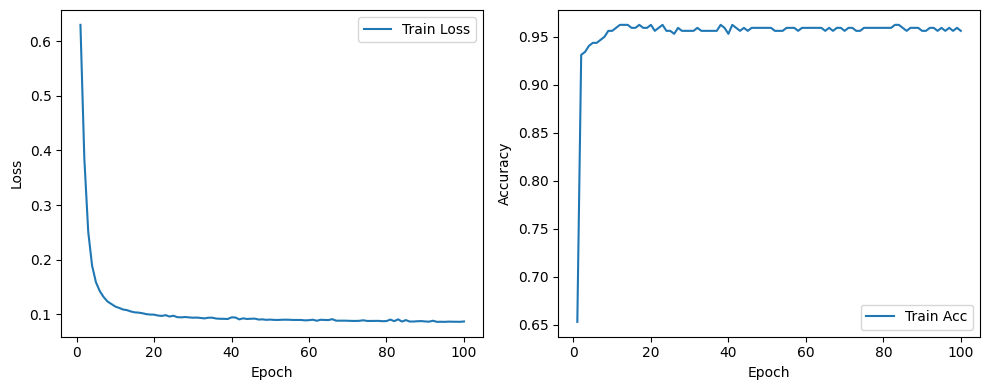

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 시드
np.random.seed(42)
torch.manual_seed(42)

# 데이터
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=1.5
)
x_train, x_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 텐서
X_clf_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_clf_train_tensor = torch.tensor(y_train, dtype=torch.float32)  # BCEWithLogitsLoss expects float labels 0.0/1.0

dataset = TensorDataset(X_clf_train_tensor, y_clf_train_tensor)
x_train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# 모델
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model_clf = BinaryClassifier(2, 16)
criterion = nn.BCEWithLogitsLoss()
optimizer_momentum = optim.SGD(model_clf.parameters(), lr=0.01, momentum=0.9)

# 학습 루프
epochs = 100
epoch_losses = []
epoch_accs = []

for epoch in range(epochs):
    model_clf.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    for data, label in x_train_loader:
        optimizer_momentum.zero_grad()
        outputs = model_clf(data).squeeze(1)          # shape (batch,)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer_momentum.step()

        epoch_loss += loss.item() * data.size(0)

        # 정확도 계산
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        epoch_correct += (preds == label).sum().item()
        epoch_samples += data.size(0)

    avg_loss = epoch_loss / epoch_samples
    avg_acc = epoch_correct / epoch_samples

    epoch_losses.append(avg_loss)
    epoch_accs.append(avg_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} Loss={avg_loss:.4f} Acc={avg_acc:.4f}")

# 시각화
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), epoch_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), epoch_accs, label='Train Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


# [7교시]

### Optimizer 성능 비교 ; iris 분류

In [15]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

scaler = StandardScaler()
iris = load_iris()
X = iris.data
y = iris.target

x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=42)
x_train = scaler.fit_transform(x_train)
# y_train = torch.transform(y_train)

x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.LongTensor(y_train)

train_dataset = TensorDataset(x_train_t,y_train_t)
train_loader = DataLoader(train_dataset,batch_size=24)

class RegressionIris(nn.Module):
    def __init__(self, input_dim, hidden_dim,output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        output = self.fc3(x)
        return output

# [8교시]

In [16]:
# 다중분류 크로스엔트로피로스
from torch.optim import SGD, Adagrad, RMSprop, Adam
model = RegressionIris(4, 16, 3)
criterion = nn.CrossEntropyLoss()

In [17]:
from tqdm import tqdm
epochs = 200; loss_list = []
sgd = SGD(model.parameters(), momentum=0)
for epoch in tqdm(range(epochs)):
    total_loss = 0.0
    for x, y in train_loader:
        sgd.zero_grad()
        predict = model(x)
        loss = criterion(predict, y)
        loss.backward()
        sgd.step()

        total_loss += loss.item()
    loss_list.append(total_loss / len(train_loader))

print(loss_list)
    

100%|██████████| 200/200 [00:00<00:00, 206.49it/s]

[1.0868250608444214, 1.086229968070984, 1.0856364011764525, 1.0850439548492432, 1.0844540119171142, 1.0838650465011597, 1.0832772254943848, 1.0826905727386475, 1.082105040550232, 1.0815188407897949, 1.0809329509735108, 1.080348253250122, 1.079764986038208, 1.0791826009750367, 1.078600859642029, 1.0780203580856322, 1.0774414539337158, 1.076863980293274, 1.0762877941131592, 1.0757125616073608, 1.0751381874084474, 1.0745646715164185, 1.0739923000335694, 1.0734202146530152, 1.072848105430603, 1.072276735305786, 1.0717058181762695, 1.0711357355117799, 1.0705663204193114, 1.0699963808059691, 1.069426918029785, 1.068858814239502, 1.0682918310165406, 1.0677255153656007, 1.0671599864959718, 1.0665950536727906, 1.0660310983657837, 1.065468955039978, 1.0649072408676148, 1.0643460035324097, 1.0637851238250733, 1.0632250547409057, 1.0626652479171752, 1.0621060848236084, 1.0615473985671997, 1.0609893560409547, 1.0604319810867309, 1.0598754405975341, 1.0593191146850587, 1.0587621688842774, 1.05820517

In [18]:
from tqdm import tqdm
epochs = 200; loss_list = []
sgd = SGD(model.parameters(),momentum=0)
momentum = SGD(model.parameters(),momentum=0.9)
adagrad = Adagrad(model.parameters())
rmsprop = RMSprop(model.parameters())
adam = Adam(model.parameters())
optim_lists = [sgd,momentum,adagrad,rmsprop,adam]

for optim in tqdm(optim_lists):
    sub_loss_list = []
    for epoch in range(epochs):
        total_loss = 0.0
        for x,y in train_loader:
            optim.zero_grad()
            predict = model(x)
            loss = criterion(predict, y)
            loss.backward()
            optim.step()

            total_loss += loss.item()
        sub_loss_list.append(total_loss / len(train_loader))
    loss_list.append(sub_loss_list)

100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


In [ ]:
sgd.__class__.__name__

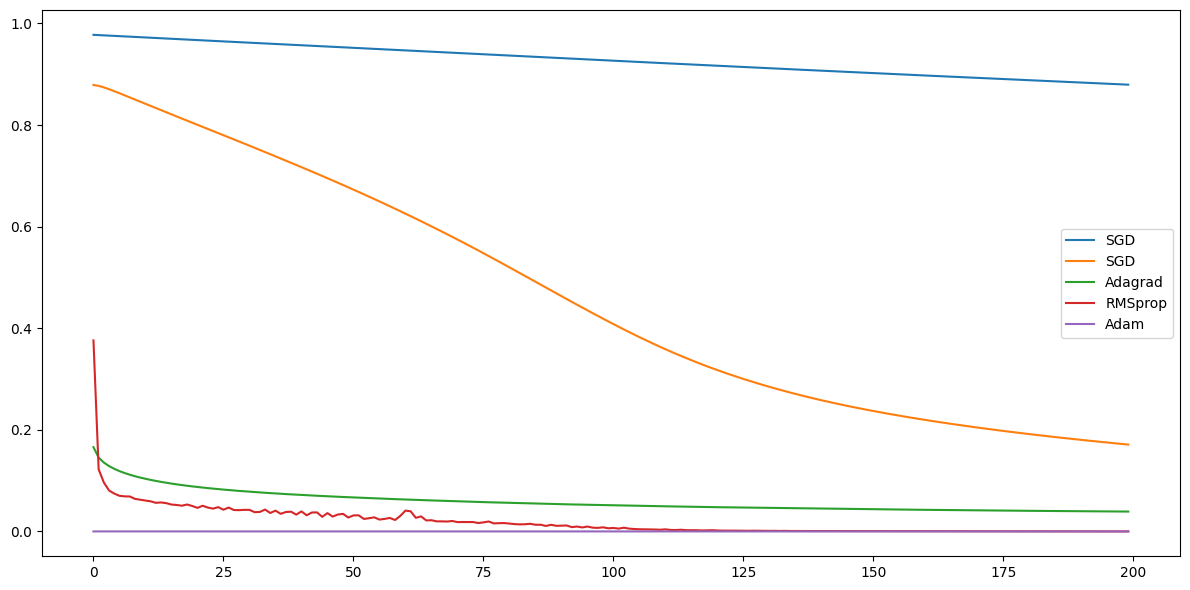

In [19]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(12,6))
for optim_loss, optim in zip(loss_list,optim_lists):
    ax.plot(range(epochs), optim_loss, label = optim.__class__.__name__ )
plt.legend()
plt.tight_layout()
plt.show()